<a href="https://colab.research.google.com/github/poonam-021/explainable-ai-stress-burnout/blob/main/models/behavourial_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
dartweichen_student_life_path = kagglehub.dataset_download('dartweichen/student-life')

print('Data source import complete.')


In [ ]:
import os

print(os.listdir('/kaggle/input'))

['datasets']


In [ ]:
import os
print(os.listdir('/kaggle/input/datasets'))

['dartweichen']


In [ ]:
import os
print(os.listdir('/kaggle/input/datasets/dartweichen'))

['student-life']


In [ ]:
import os
print(os.listdir('/kaggle/input/datasets/dartweichen/student-life'))

['dataset']


In [ ]:
import os
print(os.listdir('/kaggle/input/datasets/dartweichen/student-life/dataset'))

['EMA', 'app_usage', 'sensing', 'calendar', 'call_log', 'education', 'survey', 'dinning', 'sms']


In [ ]:
print(os.listdir('/kaggle/input/datasets/dartweichen/student-life/dataset/EMA'))

['response', 'EMA_definition.json']


In [ ]:
import os
print(os.listdir('/kaggle/input/datasets/dartweichen/student-life/dataset/EMA/response'))

['Stress', 'Exercise', 'QR_Code', 'Green Key 2', 'Class', 'PAM', 'Behavior', 'Mood 2', 'Dartmouth now', 'Study Spaces', 'Mood 1', 'Cancelled Classes', 'Class 2', 'Events', 'Boston Bombing', 'Dining Halls', 'Green Key 1', 'Administration response', 'Social', 'Lab', 'Dimensions', 'Sleep', 'Mood', 'Dimensions protestors', 'Activity', 'Comment']


In [ ]:
print(os.listdir('/kaggle/input/datasets/dartweichen/student-life/dataset/EMA/response/Stress'))

['Stress_u31.json', 'Stress_u36.json', 'Stress_u20.json', 'Stress_u22.json', 'Stress_u07.json', 'Stress_u05.json', 'Stress_u51.json', 'Stress_u27.json', 'Stress_u56.json', 'Stress_u23.json', 'Stress_u09.json', 'Stress_u54.json', 'Stress_u15.json', 'Stress_u34.json', 'Stress_u42.json', 'Stress_u30.json', 'Stress_u02.json', 'Stress_u16.json', 'Stress_u46.json', 'Stress_u58.json', 'Stress_u44.json', 'Stress_u47.json', 'Stress_u03.json', 'Stress_u19.json', 'Stress_u00.json', 'Stress_u32.json', 'Stress_u01.json', 'Stress_u49.json', 'Stress_u12.json', 'Stress_u24.json', 'Stress_u50.json', 'Stress_u17.json', 'Stress_u33.json', 'Stress_u45.json', 'Stress_u25.json', 'Stress_u08.json', 'Stress_u53.json', 'Stress_u43.json', 'Stress_u52.json', 'Stress_u57.json', 'Stress_u10.json', 'Stress_u39.json', 'Stress_u14.json', 'Stress_u59.json', 'Stress_u13.json', 'Stress_u18.json', 'Stress_u04.json', 'Stress_u41.json', 'Stress_u35.json']


In [ ]:
import os
import json
import pandas as pd

base_path = '/kaggle/input/datasets/dartweichen/student-life/dataset/EMA/response/Stress'

all_data = []

for file in os.listdir(base_path):
    if file.endswith('.json'):
        user = file.split('_')[1].split('.')[0]  # extract user id

        with open(os.path.join(base_path, file)) as f:
            data = json.load(f)

            # data is already a list
            df = pd.json_normalize(data)
            df['user'] = user

            all_data.append(df)

stress_df = pd.concat(all_data, ignore_index=True)

stress_df.head()

,null,resp_time,level,location,user
0,3,1364122031,NaN,NaN,u31
1,"43.70591546,-72.28812724",1364122034,NaN,NaN,u31
2,"43.70450657,-72.28874981",1364122032,NaN,NaN,u31
3,2,1364122036,NaN,NaN,u31
4,"43.70628474,-72.2870415",1364118589,NaN,NaN,u31


In [ ]:
# Combine level and null columns
stress_df['stress_raw'] = stress_df['level'].fillna(stress_df['null'])

# Remove rows where stress_raw is not numeric
stress_df = stress_df[pd.to_numeric(stress_df['stress_raw'], errors='coerce').notnull()]

# Convert to integer
stress_df['stress'] = stress_df['stress_raw'].astype(int)

stress_df[['stress','resp_time','user']].head()

,stress,resp_time,user
0,3,1364122031,u31
3,2,1364122036,u31
5,4,1364508024,u31
6,5,1364594440,u31
7,3,1364684254,u31


In [ ]:
# Convert UNIX timestamp to datetime
stress_df['datetime'] = pd.to_datetime(stress_df['resp_time'], unit='s')

# Extract date
stress_df['date'] = stress_df['datetime'].dt.date

stress_df[['user','stress','datetime','date']].head()

,user,stress,datetime,date
0,u31,3,2013-03-24 10:47:11,2013-03-24
3,u31,2,2013-03-24 10:47:16,2013-03-24
5,u31,4,2013-03-28 22:00:24,2013-03-28
6,u31,5,2013-03-29 22:00:40,2013-03-29
7,u31,3,2013-03-30 22:57:34,2013-03-30


In [ ]:
daily_stress = (
    stress_df
    .groupby(['user', 'date'])['stress']
    .mean()
    .reset_index()
)

daily_stress.head()

,user,date,stress
0,u00,2013-03-25,1.333333
1,u00,2013-03-26,2.000000
2,u00,2013-03-27,1.000000
3,u00,2013-03-28,2.666667
4,u00,2013-03-29,2.500000


In [ ]:
len(daily_stress)

1289

In [ ]:
daily_stress['user'].nunique()

49

In [ ]:
daily_stress['stress'].describe()

count    1289.000000
mean        2.255227
std         1.209557
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         5.000000
Name: stress, dtype: float64

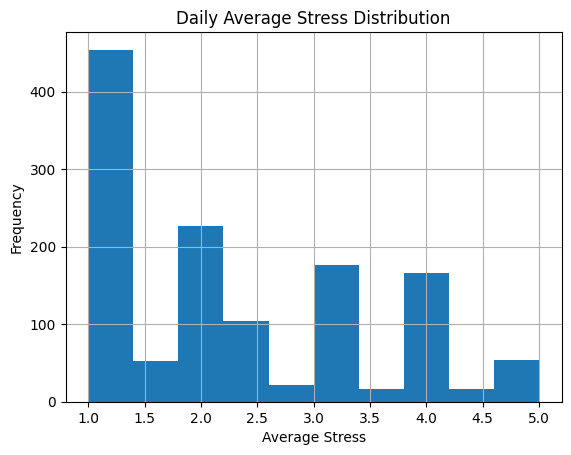

In [ ]:
import matplotlib.pyplot as plt

daily_stress['stress'].hist()
plt.title("Daily Average Stress Distribution")
plt.xlabel("Average Stress")
plt.ylabel("Frequency")
plt.show()

In [ ]:
print(os.listdir('/kaggle/input/datasets/dartweichen/student-life/dataset/app_usage'))

['running_app_u32.csv', 'running_app_u04.csv', 'running_app_u25.csv', 'running_app_u34.csv', 'running_app_u56.csv', 'running_app_u54.csv', 'running_app_u15.csv', 'running_app_u39.csv', 'running_app_u07.csv', 'running_app_u05.csv', 'running_app_u42.csv', 'running_app_u30.csv', 'running_app_u53.csv', 'running_app_u16.csv', 'running_app_u58.csv', 'running_app_u24.csv', 'running_app_u02.csv', 'running_app_u00.csv', 'running_app_u59.csv', 'running_app_u33.csv', 'running_app_u10.csv', 'running_app_u08.csv', 'running_app_u57.csv', 'running_app_u44.csv', 'running_app_u47.csv', 'running_app_u27.csv', 'running_app_u41.csv', 'running_app_u50.csv', 'running_app_u36.csv', 'running_app_u18.csv', 'running_app_u43.csv', 'running_app_u12.csv', 'running_app_u46.csv', 'running_app_u14.csv', 'running_app_u20.csv', 'running_app_u45.csv', 'running_app_u01.csv', 'running_app_u35.csv', 'running_app_u13.csv', 'running_app_u31.csv', 'running_app_u51.csv', 'running_app_u22.csv', 'running_app_u09.csv', 'running_a

In [ ]:
import pandas as pd
import os

app_path = '/kaggle/input/datasets/dartweichen/student-life/dataset/app_usage'

app_data = []

for file in os.listdir(app_path):
    if file.endswith('.csv'):
        user = file.split('_')[2].split('.')[0]  # extract user id

        df = pd.read_csv(os.path.join(app_path, file))
        df['user'] = user

        app_data.append(df)

app_df = pd.concat(app_data, ignore_index=True)

app_df.head()

,id,device,timestamp,RUNNING_TASKS_baseActivity_mClass,RUNNING_TASKS_baseActivity_mPackage,RUNNING_TASKS_id,RUNNING_TASKS_numActivities,RUNNING_TASKS_numRunning,RUNNING_TASKS_topActivity_mClass,RUNNING_TASKS_topActivity_mPackage,user
0,3d37b566-af7a-4d6d-ad8f-6465bea39265-123,dabe32a5-8e08-44d2-8617-81b0b46bf92e,1364106626,com.google.android.apps.paco.ExperimentManager...,com.google.android.apps.paco,11,1,1,com.google.android.apps.paco.ExperimentManager...,com.google.android.apps.paco,u32
1,3d37b566-af7a-4d6d-ad8f-6465bea39265-123,dabe32a5-8e08-44d2-8617-81b0b46bf92e,1364106626,com.android.launcher2.Launcher,com.android.launcher,2,1,1,com.android.launcher2.Launcher,com.android.launcher,u32
2,3d37b566-af7a-4d6d-ad8f-6465bea39265-123,dabe32a5-8e08-44d2-8617-81b0b46bf92e,1364106626,org.bewellapp.dashBoardActivity,org.bewellapp,6,1,1,org.bewellapp.dashBoardActivity,org.bewellapp,u32
3,2620c2bc-0433-4369-966c-ba8d218995e7-549,dabe32a5-8e08-44d2-8617-81b0b46bf92e,1364105426,com.android.launcher2.Launcher,com.android.launcher,2,1,1,com.android.launcher2.Launcher,com.android.launcher,u32
4,2620c2bc-0433-4369-966c-ba8d218995e7-549,dabe32a5-8e08-44d2-8617-81b0b46bf92e,1364105426,org.bewellapp.dashBoardActivity,org.bewellapp,6,1,1,org.bewellapp.dashBoardActivity,org.bewellapp,u32


In [ ]:
# Keep only required columns
app_df = app_df[['user', 'timestamp', 'RUNNING_TASKS_topActivity_mPackage']]

# Rename for simplicity
app_df.rename(columns={
    'RUNNING_TASKS_topActivity_mPackage': 'app'
}, inplace=True)

app_df.head()

,user,timestamp,app
0,u32,1364106626,com.google.android.apps.paco
1,u32,1364106626,com.android.launcher
2,u32,1364106626,org.bewellapp
3,u32,1364105426,com.android.launcher
4,u32,1364105426,org.bewellapp


In [ ]:
app_df['datetime'] = pd.to_datetime(app_df['timestamp'], unit='s')
app_df['date'] = app_df['datetime'].dt.date

app_df.head()

,user,timestamp,app,datetime,date
0,u32,1364106626,com.google.android.apps.paco,2013-03-24 06:30:26,2013-03-24
1,u32,1364106626,com.android.launcher,2013-03-24 06:30:26,2013-03-24
2,u32,1364106626,org.bewellapp,2013-03-24 06:30:26,2013-03-24
3,u32,1364105426,com.android.launcher,2013-03-24 06:10:26,2013-03-24
4,u32,1364105426,org.bewellapp,2013-03-24 06:10:26,2013-03-24


In [ ]:
daily_app = (
    app_df
    .groupby(['user', 'date'])
    .agg(
        total_app_events=('app', 'count'),
        unique_apps=('app', 'nunique')
    )
    .reset_index()
)

daily_app.head()

,user,date,total_app_events,unique_apps
0,u00,2013-03-24,472,22
1,u00,2013-03-25,630,21
2,u00,2013-03-26,737,12
3,u00,2013-03-27,780,19
4,u00,2013-03-28,865,25


In [ ]:
len(daily_app)

3083

In [ ]:
daily_app.describe()

,total_app_events,unique_apps
count,3083.00000,3083.000000
mean,645.64061,12.421992
std,556.58455,7.906084
min,1.00000,1.000000
25%,263.00000,7.000000
50%,498.00000,11.000000
75%,868.50000,17.000000
max,4136.00000,58.000000


In [ ]:
merged_df = pd.merge(daily_stress, daily_app, on=['user','date'], how='inner')

merged_df.head()

,user,date,stress,total_app_events,unique_apps
0,u00,2013-03-25,1.333333,630,21
1,u00,2013-03-26,2.000000,737,12
2,u00,2013-03-27,1.000000,780,19
3,u00,2013-03-28,2.666667,865,25
4,u00,2013-03-29,2.500000,705,16


In [ ]:
len(merged_df)

1263

In [ ]:
merged_df.describe()

,stress,total_app_events,unique_apps
count,1263.000000,1263.000000,1263.000000
mean,2.250188,769.904196,14.331750
std,1.210031,607.656091,8.248325
min,1.000000,22.000000,2.000000
25%,1.000000,331.500000,8.000000
50%,2.000000,618.000000,13.000000
75%,3.000000,1034.000000,19.000000
max,5.000000,4136.000000,58.000000


In [ ]:
merged_df[['stress','total_app_events','unique_apps']].corr()

,stress,total_app_events,unique_apps
stress,1.000000,0.029711,0.042363
total_app_events,0.029711,1.000000,0.884650
unique_apps,0.042363,0.884650,1.000000


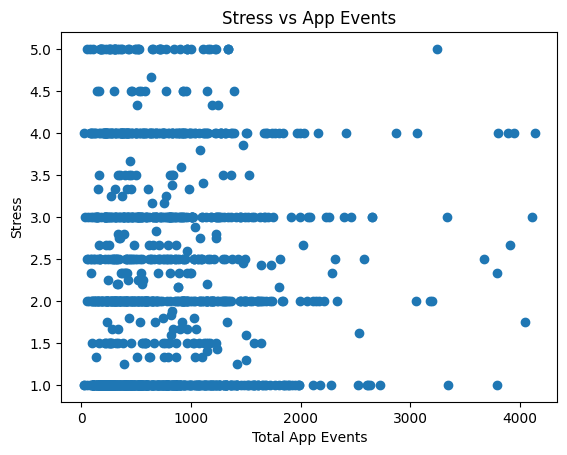

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(merged_df['total_app_events'], merged_df['stress'])
plt.xlabel("Total App Events")
plt.ylabel("Stress")
plt.title("Stress vs App Events")
plt.show()

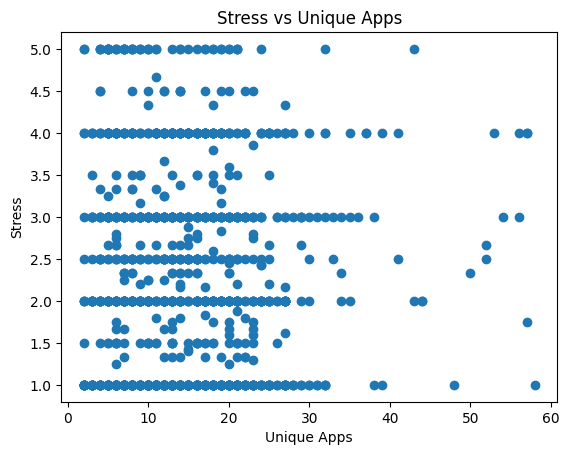

In [ ]:
plt.scatter(merged_df['unique_apps'], merged_df['stress'])
plt.xlabel("Unique Apps")
plt.ylabel("Stress")
plt.title("Stress vs Unique Apps")
plt.show()

In [ ]:
merged_df.isnull().sum()

user                0
date                0
stress              0
total_app_events    0
unique_apps         0
dtype: int64

In [ ]:
import os
print(os.listdir('/kaggle/input/datasets/dartweichen/student-life/dataset/call_log'))

['call_log_u51.csv', 'call_log_u44.csv', 'call_log_u45.csv', 'call_log_u56.csv', 'call_log_u10.csv', 'call_log_u32.csv', 'call_log_u09.csv', 'call_log_u27.csv', 'call_log_u13.csv', 'call_log_u23.csv', 'call_log_u59.csv', 'call_log_u24.csv', 'call_log_u54.csv', 'call_log_u22.csv', 'call_log_u46.csv', 'call_log_u57.csv', 'call_log_u18.csv', 'call_log_u15.csv', 'call_log_u16.csv', 'call_log_u08.csv', 'call_log_u04.csv', 'call_log_u01.csv', 'call_log_u58.csv', 'call_log_u14.csv', 'call_log_u05.csv', 'call_log_u25.csv', 'call_log_u17.csv', 'call_log_u52.csv', 'call_log_u00.csv', 'call_log_u20.csv', 'call_log_u03.csv', 'call_log_u53.csv', 'call_log_u30.csv', 'call_log_u33.csv', 'call_log_u19.csv', 'call_log_u36.csv', 'call_log_u12.csv', 'call_log_u34.csv', 'call_log_u39.csv', 'call_log_u47.csv', 'call_log_u50.csv', 'call_log_u49.csv', 'call_log_u35.csv', 'call_log_u43.csv', 'call_log_u41.csv', 'call_log_u07.csv', 'call_log_u31.csv', 'call_log_u42.csv', 'call_log_u02.csv']


In [ ]:
import pandas as pd
import os

call_path = '/kaggle/input/datasets/dartweichen/student-life/dataset/call_log'

call_data = []

for file in os.listdir(call_path):
    if file.endswith('.csv'):
        user = file.split('_')[2].split('.')[0]   # extract user id

        df = pd.read_csv(os.path.join(call_path, file))
        df['user'] = user

        call_data.append(df)

call_df = pd.concat(call_data, ignore_index=True)

call_df.head()

,id,device,timestamp,CALLS__id,CALLS_date,CALLS_duration,CALLS_name,CALLS_number,CALLS_numberlabel,CALLS_numbertype,CALLS_type,user
0,d9f1a614-5c8d-4347-bb97-67b6f3f47e81-18,8f85f240-20d3-424f-8552-d6eec3807377,1364102763,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,u51
1,30bfc36d-b204-4c50-90db-6b21a5244a3d-37,8f85f240-20d3-424f-8552-d6eec3807377,1364142363,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,u51
2,27844f1d-28a8-4c6a-a616-49e8402bacce-35,8f85f240-20d3-424f-8552-d6eec3807377,1364138763,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,u51
3,d51a138f-98d5-48d6-9a9f-503073764182-36,8f85f240-20d3-424f-8552-d6eec3807377,1364124363,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,u51
4,1edaf7f3-2c15-4a59-af8f-99586d1478a5-36,8f85f240-20d3-424f-8552-d6eec3807377,1364120763,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,u51


In [ ]:
# Keep only necessary columns
call_df = call_df[['user','timestamp']]

call_df.head()

,user,timestamp
0,u51,1364102763
1,u51,1364142363
2,u51,1364138763
3,u51,1364124363
4,u51,1364120763


In [ ]:
# Convert timestamp to datetime
call_df['datetime'] = pd.to_datetime(call_df['timestamp'], unit='s')

# Extract date
call_df['date'] = call_df['datetime'].dt.date

call_df.head()

,user,timestamp,datetime,date
0,u51,1364102763,2013-03-24 05:26:03,2013-03-24
1,u51,1364142363,2013-03-24 16:26:03,2013-03-24
2,u51,1364138763,2013-03-24 15:26:03,2013-03-24
3,u51,1364124363,2013-03-24 11:26:03,2013-03-24
4,u51,1364120763,2013-03-24 10:26:03,2013-03-24


In [ ]:
daily_calls = (
    call_df
    .groupby(['user','date'])
    .size()
    .reset_index(name='daily_call_count')
)

daily_calls.head()

,user,date,daily_call_count
0,u00,2013-03-23,213
1,u00,2013-03-24,21
2,u00,2013-03-25,23
3,u00,2013-03-26,26
4,u00,2013-03-27,27


In [ ]:
merged_df.head()

,user,date,stress,total_app_events,unique_apps
0,u00,2013-03-25,1.333333,630,21
1,u00,2013-03-26,2.000000,737,12
2,u00,2013-03-27,1.000000,780,19
3,u00,2013-03-28,2.666667,865,25
4,u00,2013-03-29,2.500000,705,16


In [ ]:
merged_df = pd.merge(merged_df, daily_calls, on=['user','date'], how='left')

merged_df.head()

,user,date,stress,total_app_events,unique_apps,daily_call_count
0,u00,2013-03-25,1.333333,630,21,23.0
1,u00,2013-03-26,2.000000,737,12,26.0
2,u00,2013-03-27,1.000000,780,19,27.0
3,u00,2013-03-28,2.666667,865,25,27.0
4,u00,2013-03-29,2.500000,705,16,25.0


In [ ]:
merged_df['daily_call_count'] = merged_df['daily_call_count'].fillna(0)

In [ ]:
merged_df.head()

,user,date,stress,total_app_events,unique_apps,daily_call_count
0,u00,2013-03-25,1.333333,630,21,23.0
1,u00,2013-03-26,2.000000,737,12,26.0
2,u00,2013-03-27,1.000000,780,19,27.0
3,u00,2013-03-28,2.666667,865,25,27.0
4,u00,2013-03-29,2.500000,705,16,25.0


In [ ]:
import os
print(os.listdir('/kaggle/input/datasets/dartweichen/student-life/dataset/sms'))

['sms_u08.csv', 'sms_u14.csv', 'sms_u30.csv', 'sms_u27.csv', 'sms_u45.csv', 'sms_u19.csv', 'sms_u01.csv', 'sms_u07.csv', 'sms_u34.csv', 'sms_u42.csv', 'sms_u33.csv', 'sms_u00.csv', 'sms_u54.csv', 'sms_u20.csv', 'sms_u32.csv', 'sms_u47.csv', 'sms_u43.csv', 'sms_u13.csv', 'sms_u35.csv', 'sms_u51.csv', 'sms_u41.csv', 'sms_u16.csv', 'sms_u23.csv', 'sms_u52.csv', 'sms_u10.csv', 'sms_u53.csv', 'sms_u04.csv', 'sms_u58.csv', 'sms_u59.csv', 'sms_u15.csv', 'sms_u03.csv', 'sms_u25.csv', 'sms_u05.csv', 'sms_u36.csv', 'sms_u09.csv', 'sms_u50.csv', 'sms_u17.csv', 'sms_u57.csv', 'sms_u31.csv', 'sms_u22.csv', 'sms_u24.csv', 'sms_u46.csv', 'sms_u49.csv', 'sms_u12.csv', 'sms_u56.csv', 'sms_u44.csv', 'sms_u39.csv', 'sms_u02.csv', 'sms_u18.csv']


In [ ]:
import pandas as pd
import os

sms_path = '/kaggle/input/datasets/dartweichen/student-life/dataset/sms'

sms_data = []

for file in os.listdir(sms_path):
    if file.endswith('.csv'):
        user = file.split('_')[1].split('.')[0]   # extract user id

        df = pd.read_csv(os.path.join(sms_path, file))
        df['user'] = user

        sms_data.append(df)

sms_df = pd.concat(sms_data, ignore_index=True)

sms_df.head()

,id,device,timestamp,MESSAGES_address,MESSAGES_body,MESSAGES_date,MESSAGES_locked,MESSAGES_person,MESSAGES_protocol,MESSAGES_read,MESSAGES_reply_path_present,MESSAGES_service_center,MESSAGES_status,MESSAGES_subject,MESSAGES_thread_id,MESSAGES_type,user
0,017da016-cc35-46ae-9733-66b6e9ba629d-17,d5650781-2998-4c7b-973e-d3b26096bcb7,1364095718,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,u08
1,c0dbe92d-5cbc-490a-9c8b-9a1bdf7cd402-63,d5650781-2998-4c7b-973e-d3b26096bcb7,1364106518,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,u08
2,1fbae109-68be-444e-82e4-bdd5ed12215a-82,d5650781-2998-4c7b-973e-d3b26096bcb7,1364099318,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,u08
3,b422bedc-3db9-4e3c-a6b0-4044e4f24612-26,d5650781-2998-4c7b-973e-d3b26096bcb7,1364102918,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,u08
4,c8c5bcfd-7eec-40ac-9d65-b901850aed3b-19,d5650781-2998-4c7b-973e-d3b26096bcb7,1364110118,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,u08


In [ ]:
sms_df = sms_df[['user','timestamp']]

sms_df.head()

,user,timestamp
0,u08,1364095718
1,u08,1364106518
2,u08,1364099318
3,u08,1364102918
4,u08,1364110118


In [ ]:
sms_df['datetime'] = pd.to_datetime(sms_df['timestamp'], unit='s')
sms_df['date'] = sms_df['datetime'].dt.date

sms_df.head()

,user,timestamp,datetime,date
0,u08,1364095718,2013-03-24 03:28:38,2013-03-24
1,u08,1364106518,2013-03-24 06:28:38,2013-03-24
2,u08,1364099318,2013-03-24 04:28:38,2013-03-24
3,u08,1364102918,2013-03-24 05:28:38,2013-03-24
4,u08,1364110118,2013-03-24 07:28:38,2013-03-24


In [ ]:
daily_sms = (
    sms_df
    .groupby(['user','date'])
    .size()
    .reset_index(name='daily_sms_count')
)

daily_sms.head()

,user,date,daily_sms_count
0,u00,2013-03-22,56
1,u00,2013-03-24,20
2,u00,2013-03-25,23
3,u00,2013-03-26,24
4,u00,2013-03-27,24


In [ ]:
merged_df = pd.merge(merged_df, daily_sms, on=['user','date'], how='left')

In [ ]:
merged_df.shape

(1263, 7)

In [ ]:
merged_df.columns

Index(['user', 'date', 'stress', 'total_app_events', 'unique_apps',
       'daily_call_count', 'daily_sms_count'],
      dtype='object')

In [ ]:
merged_df.columns

Index(['user', 'date', 'stress', 'total_app_events', 'unique_apps',
       'daily_call_count', 'daily_sms_count'],
      dtype='object')

In [ ]:
corr = merged_df[['stress',
                  'total_app_events',
                  'unique_apps',
                  'daily_call_count',
                  'daily_sms_count']].corr()

corr

,stress,total_app_events,unique_apps,daily_call_count,daily_sms_count
stress,1.000000,0.029711,0.042363,-0.037462,0.012383
total_app_events,0.029711,1.000000,0.884650,0.256075,0.165381
unique_apps,0.042363,0.884650,1.000000,0.209405,0.237678
daily_call_count,-0.037462,0.256075,0.209405,1.000000,0.449466
daily_sms_count,0.012383,0.165381,0.237678,0.449466,1.000000


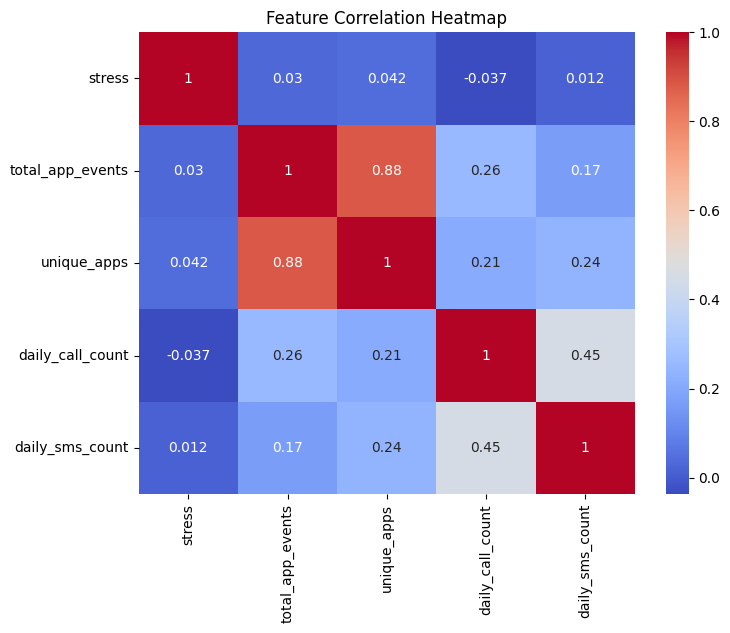

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

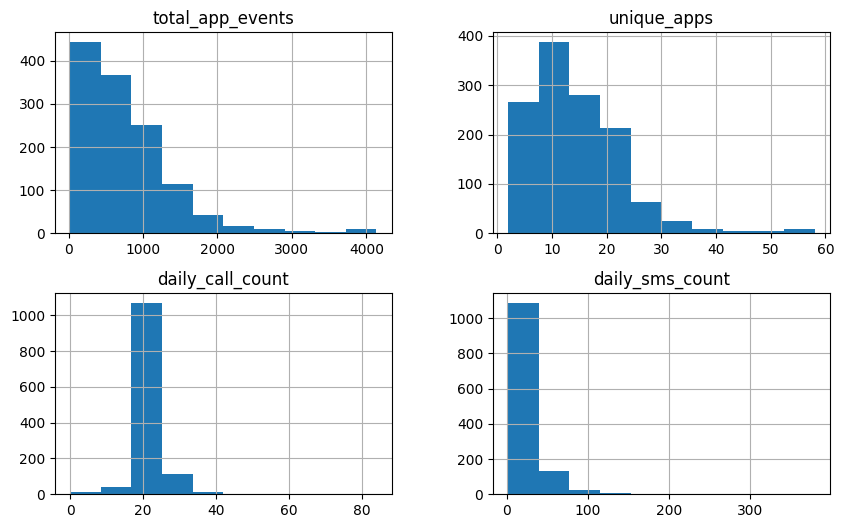

In [ ]:
merged_df[['total_app_events',
           'unique_apps',
           'daily_call_count',
           'daily_sms_count']].hist(figsize=(10,6))

plt.show()

In [ ]:
merged_df.columns

Index(['user', 'date', 'stress', 'total_app_events', 'unique_apps',
       'daily_call_count', 'daily_sms_count'],
      dtype='object')

In [ ]:
merged_df.shape

(1263, 7)

In [ ]:
merged_df.isnull().sum()

user                0
date                0
stress              0
total_app_events    0
unique_apps         0
daily_call_count    0
daily_sms_count     2
dtype: int64

In [ ]:
merged_df['daily_sms_count'] = merged_df['daily_sms_count'].fillna(0)

In [ ]:
merged_df.isnull().sum()

user                0
date                0
stress              0
total_app_events    0
unique_apps         0
daily_call_count    0
daily_sms_count     0
dtype: int64

In [ ]:
ml_df = merged_df.drop(columns=['user','date'])

In [ ]:
ml_df.head()

,stress,total_app_events,unique_apps,daily_call_count,daily_sms_count
0,1.333333,630,21,23.0,23.0
1,2.000000,737,12,26.0,24.0
2,1.000000,780,19,27.0,24.0
3,2.666667,865,25,27.0,23.0
4,2.500000,705,16,25.0,24.0


In [ ]:
X = ml_df.drop(columns=['stress'])
y = ml_df['stress']

In [ ]:
X.shape
y.shape

(1263,)

In [ ]:
X.shape

(1263, 4)

In [ ]:
X.head()

,total_app_events,unique_apps,daily_call_count,daily_sms_count
0,630,21,23.0,23.0
1,737,12,26.0,24.0
2,780,19,27.0,24.0
3,865,25,27.0,23.0
4,705,16,25.0,24.0


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
X_train.shape
X_test.shape

(253, 4)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)

MAE: 1.0717929063964142
MSE: 1.7651054563734634


In [ ]:
import pandas as pd

importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': importance
}).sort_values(by='importance', ascending=False)

feature_importance

,feature,importance
0,total_app_events,0.562965
1,unique_apps,0.226799
3,daily_sms_count,0.120859
2,daily_call_count,0.089377


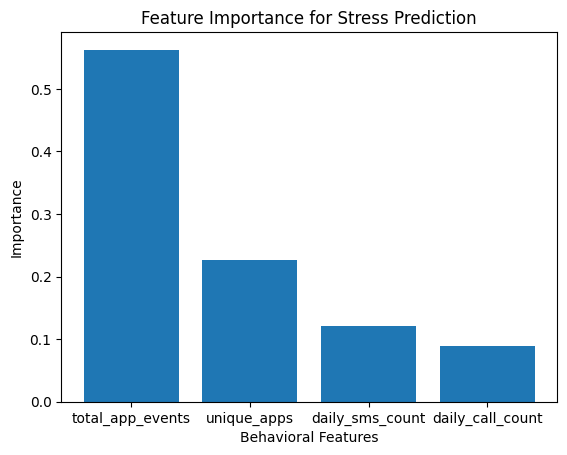

In [ ]:
import matplotlib.pyplot as plt

plt.bar(feature_importance['feature'], feature_importance['importance'])
plt.title("Feature Importance for Stress Prediction")
plt.xlabel("Behavioral Features")
plt.ylabel("Importance")
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor()

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error

rf_mae = mean_absolute_error(y_test, y_pred)
lr_mae = mean_absolute_error(y_test, lr_pred)
gb_mae = mean_absolute_error(y_test, gb_pred)

print("Random Forest MAE:", rf_mae)
print("Linear Regression MAE:", lr_mae)
print("Gradient Boosting MAE:", gb_mae)

Random Forest MAE: 1.0717929063964142
Linear Regression MAE: 1.0159667383748816
Gradient Boosting MAE: 1.030688499370062


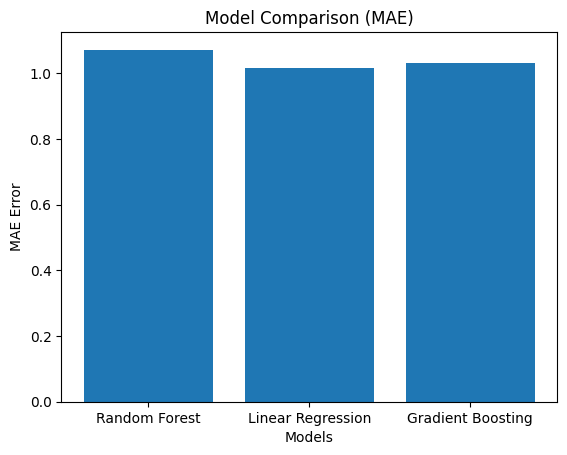

In [ ]:
import matplotlib.pyplot as plt

models = ['Random Forest', 'Linear Regression', 'Gradient Boosting']
mae_scores = [rf_mae, lr_mae, gb_mae]

plt.bar(models, mae_scores)

plt.title("Model Comparison (MAE)")
plt.xlabel("Models")
plt.ylabel("MAE Error")

plt.show()

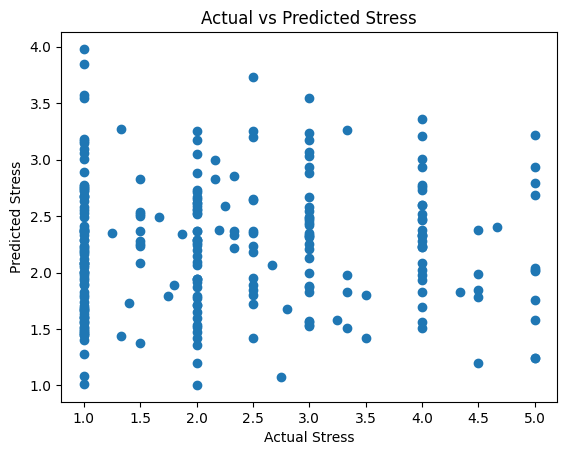

In [ ]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Stress")
plt.ylabel("Predicted Stress")

plt.title("Actual vs Predicted Stress")

plt.show()

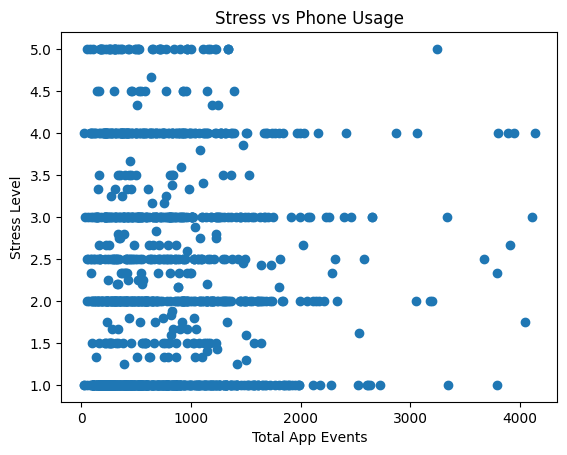

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(merged_df['total_app_events'], merged_df['stress'])

plt.xlabel("Total App Events")
plt.ylabel("Stress Level")

plt.title("Stress vs Phone Usage")

plt.show()

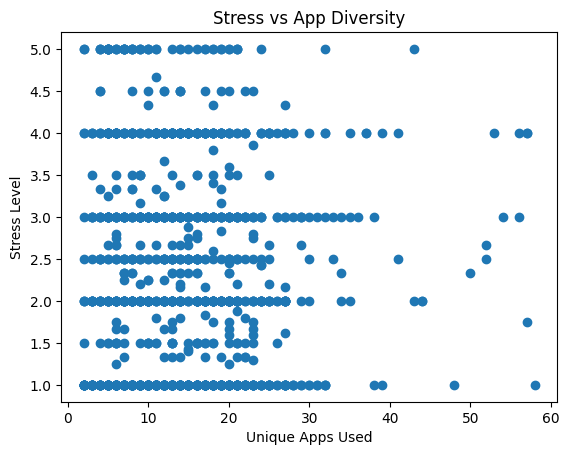

In [ ]:
plt.scatter(merged_df['unique_apps'], merged_df['stress'])

plt.xlabel("Unique Apps Used")
plt.ylabel("Stress Level")

plt.title("Stress vs App Diversity")

plt.show()

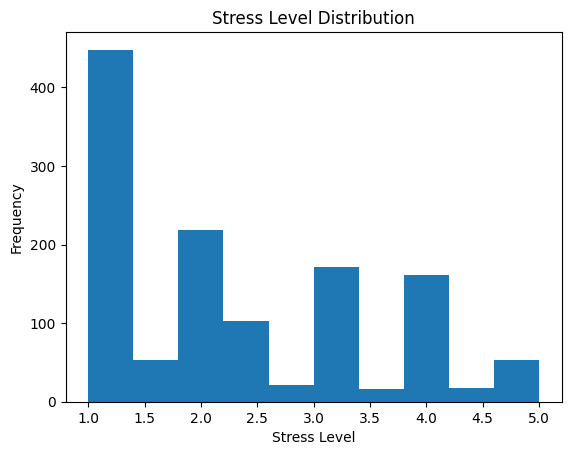

In [ ]:
plt.hist(merged_df['stress'], bins=10)

plt.xlabel("Stress Level")
plt.ylabel("Frequency")

plt.title("Stress Level Distribution")

plt.show()